# 04 - Grad-CAM Visualization

Grad-CAM shows *where* the model looks when it makes a prediction.
We compute gradients of the predicted class score w.r.t. the last conv layer —
regions with large gradients are what the model found most useful.

This helps us check if the model actually learned the pattern shapes,
or just picked up on background noise.

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models, datasets

# checkpoints come from Drive, data from local /content/
try:
    from google.colab import drive
    drive.mount('/drive')
    CKPT_DIR    = Path('/drive/MyDrive/ECE176/checkpoints')
    RESULTS_DIR = Path('/content/results')
except ImportError:
    CKPT_DIR    = Path('.').resolve() / 'checkpoints'
    RESULTS_DIR = Path('.').resolve() / 'results'

SYNTHETIC_DIR = Path('/content/data/synthetic')
IMG_SIZE = 224
CLASS_NAMES = [
    'head_and_shoulders', 'double_top', 'descending_triangle',
    'inv_head_and_shoulders', 'double_bottom', 'ascending_triangle', 'no_pattern',
]
N_CLASSES = len(CLASS_NAMES)

os.makedirs(RESULTS_DIR / 'figures', exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else
                       'mps'  if torch.backends.mps.is_available() else 'cpu')
print(f'Device      : {device}')
print(f'Checkpoints : {CKPT_DIR}')


Drive already mounted at /drive; to attempt to forcibly remount, call drive.mount("/drive", force_remount=True).
Device      : cuda
Checkpoints : /drive/MyDrive/ECE176/checkpoints


In [10]:
class PatternCNN(nn.Module):
    def __init__(self, n_classes=N_CLASSES, dropout=0.5):
        super().__init__()
        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )
        self.features = nn.Sequential(
            conv_block(3, 32), conv_block(32, 64), conv_block(64, 128),
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(128, 256),
            nn.ReLU(inplace=True), nn.Dropout(dropout), nn.Linear(256, n_classes),
        )
    def forward(self, x):
        return self.classifier(self.gap(self.features(x)))


def build_resnet18(n_classes=N_CLASSES):
    m = models.resnet18(weights=None)
    m.fc = nn.Linear(512, n_classes)
    return m


cnn_model = PatternCNN().to(device)
cnn_model.load_state_dict(torch.load(CKPT_DIR / 'cnn_best.pt', map_location=device))
cnn_model.eval()

resnet_model = build_resnet18().to(device)
resnet_model.load_state_dict(torch.load(CKPT_DIR / 'resnet_best.pt', map_location=device))
resnet_model.eval()

print('Both models loaded!')


Both models loaded!


## Grad-CAM

Steps:
1. Hook the last conv layer to capture its output (feature maps) on forward pass
2. Hook it again to capture gradients on backward pass
3. Average-pool the gradients across spatial dims → per-channel importance weights
4. Weighted sum of feature maps → heatmap → resize to 224×224

In [11]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.fmaps = None
        self.grads = None
        self.h1 = target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'fmaps', o.detach())
        )
        self.h2 = target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, 'grads', go[0].detach())
        )

    def __call__(self, img_tensor, class_idx=None):
        self.model.zero_grad()
        out = self.model(img_tensor)
        if class_idx is None:
            class_idx = out.argmax(1).item()
        out[0, class_idx].backward()

        weights = self.grads.mean(dim=[2, 3], keepdim=True)
        cam = F.relu((weights * self.fmaps).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, (IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx

    def remove(self):
        self.h1.remove()
        self.h2.remove()


def make_overlay(img_tensor, cam, alpha=0.5):
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = img_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    img  = (img * std + mean).clip(0, 1)
    heat = cm.jet(cam)[:, :, :3]
    return (alpha * heat + (1 - alpha) * img).clip(0, 1), img


tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

print('GradCAM ready')


GradCAM ready


## One Sample per Class

For each pattern class we pick one val image and show:
original → CNN heatmap → CNN overlay → ResNet heatmap → ResNet overlay

Good sign: heatmap highlights the actual pattern shape (peaks, valleys, triangles)

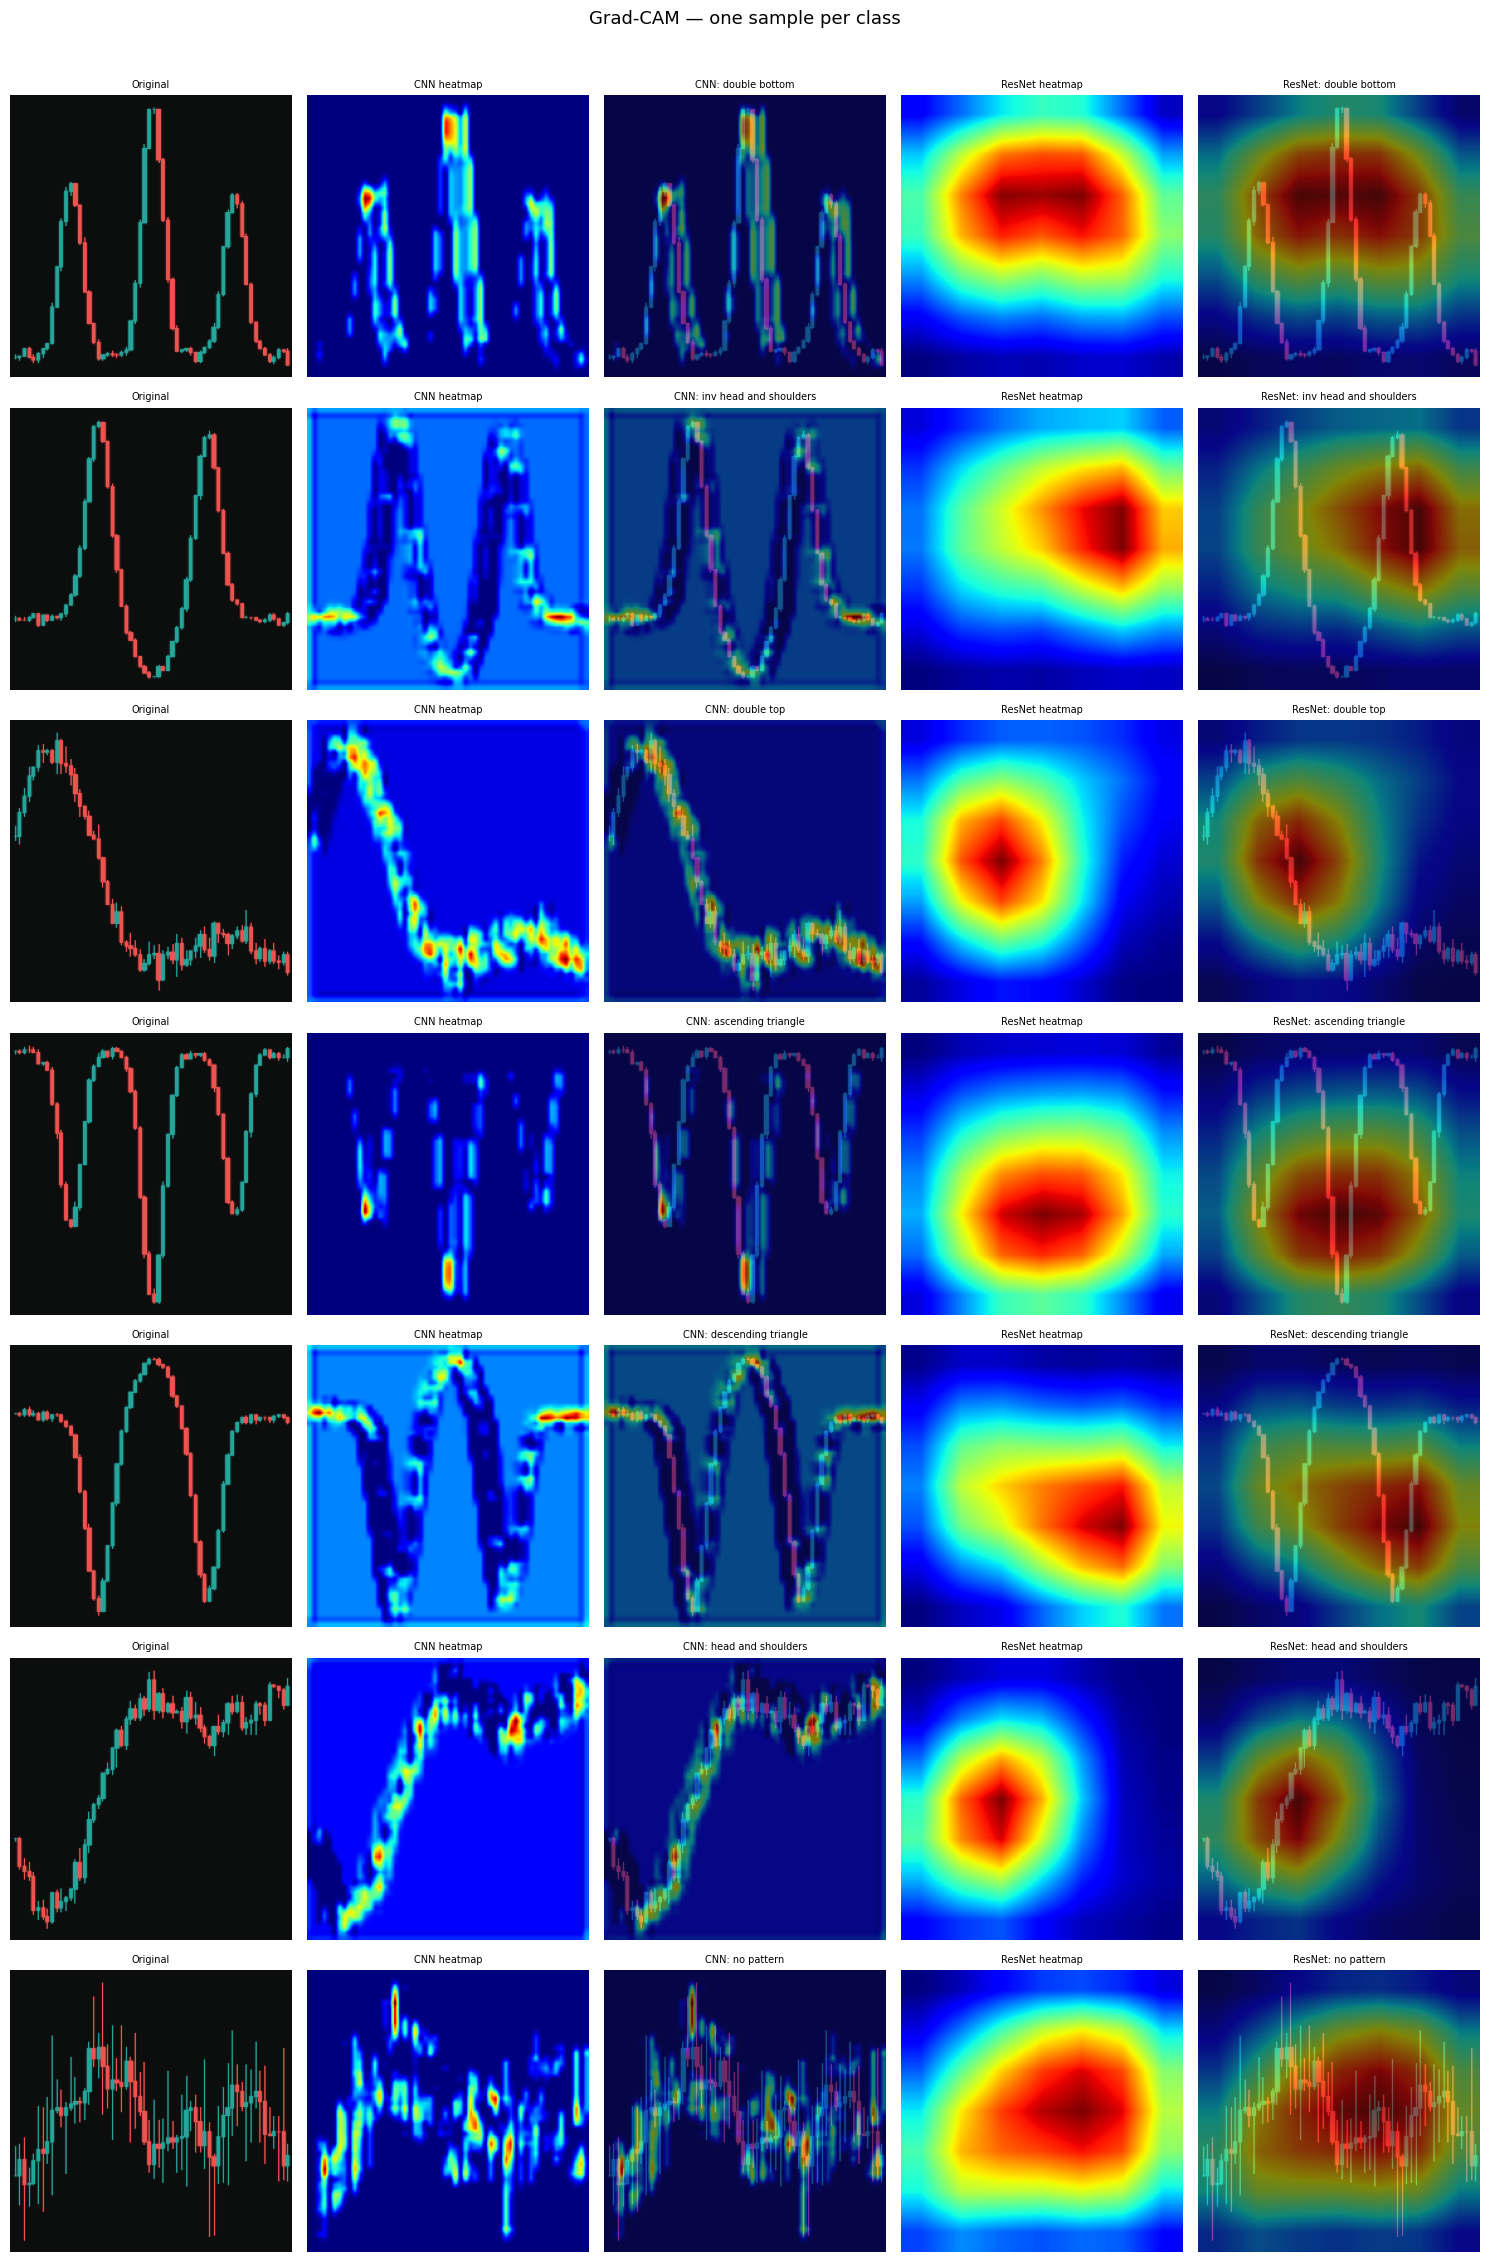

Saved gradcam_per_class.png


In [12]:
assert (SYNTHETIC_DIR / 'val').exists(), (
    "Synthetic data not found at /content/data/synthetic/val\n"
    "Run notebook 01 first to generate the data, then re-run this cell."
)

cnn_cam    = GradCAM(cnn_model,    cnn_model.features[-1][0])
resnet_cam = GradCAM(resnet_model, resnet_model.layer4[-1].conv2)

fig, axes = plt.subplots(len(CLASS_NAMES), 5, figsize=(15, 3.2 * len(CLASS_NAMES)))

for row, cls in enumerate(CLASS_NAMES):
    img_path   = sorted((SYNTHETIC_DIR / 'val' / cls).glob('*.png'))[0]
    img_tensor = tfm(Image.open(img_path).convert('RGB')).unsqueeze(0).to(device)

    cam_c, pred_c = cnn_cam(img_tensor)
    cam_r, pred_r = resnet_cam(img_tensor)

    ov_c, orig = make_overlay(img_tensor, cam_c)
    ov_r, _    = make_overlay(img_tensor, cam_r)

    for ax, data, title in zip(
        axes[row],
        [orig, cam_c, ov_c, cam_r, ov_r],
        ['Original',
         'CNN heatmap',
         f'CNN: {CLASS_NAMES[pred_c].replace("_"," ")}',
         'ResNet heatmap',
         f'ResNet: {CLASS_NAMES[pred_r].replace("_"," ")}'],
    ):
        ax.imshow(data, cmap='jet' if 'heatmap' in title else None)
        ax.set_title(title, fontsize=7)
        ax.axis('off')

    axes[row, 0].set_ylabel(cls.replace('_', '\n'), fontsize=7,
                             rotation=0, labelpad=55, va='center')

plt.suptitle('Grad-CAM — one sample per class', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'gradcam_per_class.png', dpi=100, bbox_inches='tight')
plt.show()

cnn_cam.remove()
resnet_cam.remove()
print('Saved gradcam_per_class.png')


## Low-Confidence Predictions

Since the model hits 100% on synthetic val data, there are no wrong predictions to look at.
Instead we find the 4 images the model was **least confident** about — even if it got them right.
The heatmap shows what the model focused on when it was uncertain.


4 lowest-confidence predictions:
  conf=0.683  true=head_and_shoulders  pred=head_and_shoulders
  conf=0.711  true=inv_head_and_shoulders  pred=inv_head_and_shoulders
  conf=0.793  true=inv_head_and_shoulders  pred=inv_head_and_shoulders
  conf=0.797  true=inv_head_and_shoulders  pred=inv_head_and_shoulders


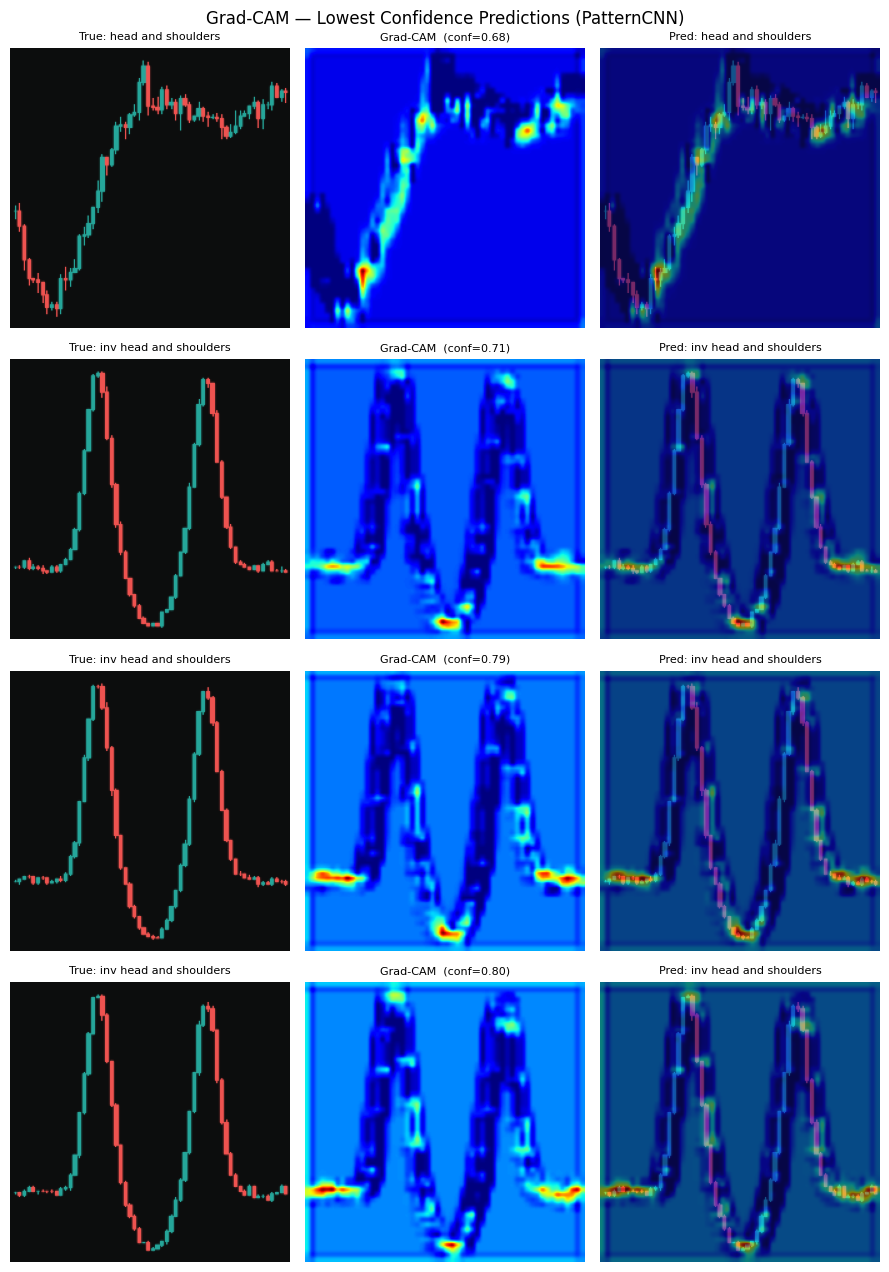

Saved gradcam_low_conf.png


In [13]:
# Since our model hits 100% on synthetic val, there are no misclassified samples.
# Instead we look at the predictions the model was LEAST confident about —
# these are the most informative for understanding model behaviour.

val_ds = datasets.ImageFolder(SYNTHETIC_DIR / 'val', transform=tfm)

scores = []  # (confidence, img_tensor, true_label, pred_label)
with torch.no_grad():
    for idx in range(len(val_ds)):
        img, true_lbl = val_ds[idx]
        img_t  = img.unsqueeze(0).to(device)
        probs  = torch.softmax(cnn_model(img_t), dim=1)
        conf, pred = probs.max(1)
        scores.append((conf.item(), img_t, true_lbl, pred.item()))

# sort by confidence ascending — least confident first
scores.sort(key=lambda x: x[0])
low_conf = scores[:4]

print('4 lowest-confidence predictions:')
for conf, _, true_lbl, pred_lbl in low_conf:
    print(f'  conf={conf:.3f}  true={CLASS_NAMES[true_lbl]}  pred={CLASS_NAMES[pred_lbl]}')

cnn_cam = GradCAM(cnn_model, cnn_model.features[-1][0])
fig, axes = plt.subplots(4, 3, figsize=(9, 13))

for row, (conf, img_tensor, true_lbl, pred_lbl) in enumerate(low_conf):
    cam, _ = cnn_cam(img_tensor, class_idx=pred_lbl)
    overlay, orig = make_overlay(img_tensor, cam)

    axes[row, 0].imshow(orig)
    axes[row, 0].set_title(f'True: {CLASS_NAMES[true_lbl].replace("_"," ")}', fontsize=8)
    axes[row, 1].imshow(cam, cmap='jet')
    axes[row, 1].set_title(f'Grad-CAM  (conf={conf:.2f})', fontsize=8)
    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title(f'Pred: {CLASS_NAMES[pred_lbl].replace("_"," ")}', fontsize=8)
    for ax in axes[row]: ax.axis('off')

plt.suptitle('Grad-CAM — Lowest Confidence Predictions (PatternCNN)', fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'gradcam_low_conf.png', dpi=100, bbox_inches='tight')
plt.show()

cnn_cam.remove()
print('Saved gradcam_low_conf.png')


## Average Grad-CAM per Class

Averaging over 10 samples smooths out noise and shows the *typical* attention region
for each pattern class.

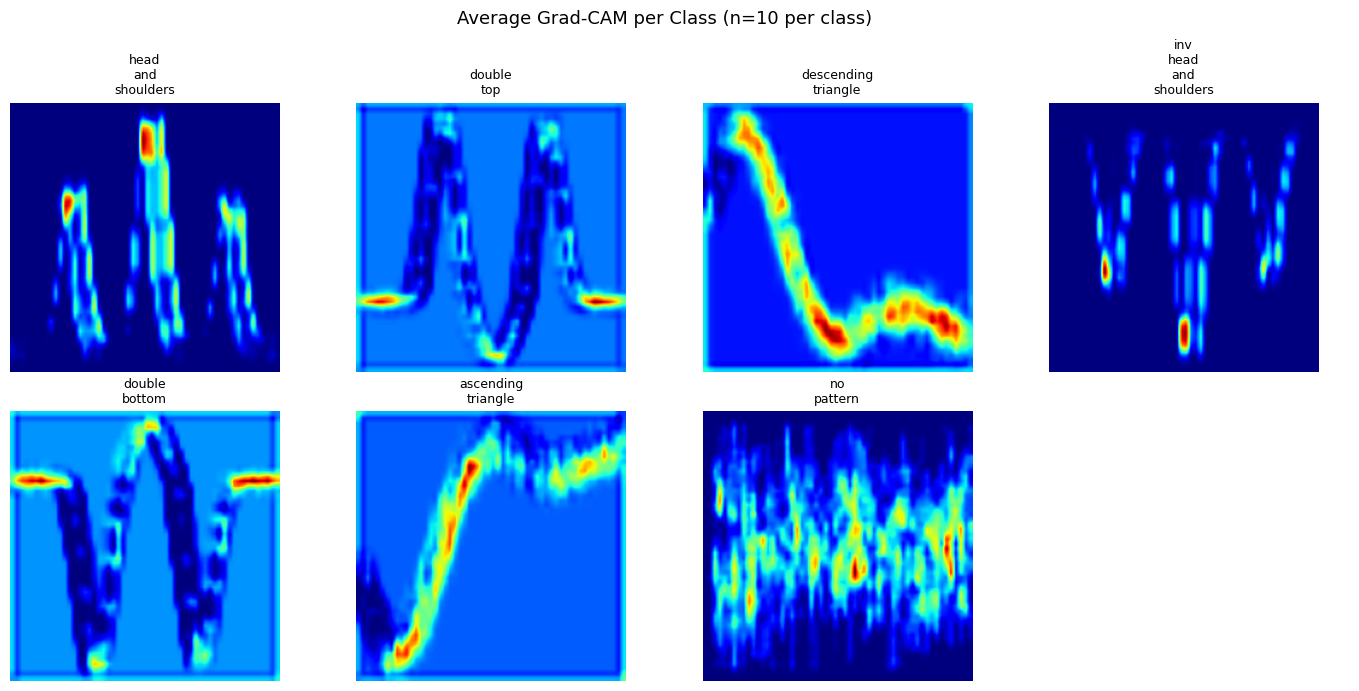

Saved gradcam_avg.png


In [14]:
N = 10
cnn_cam = GradCAM(cnn_model, cnn_model.features[-1][0])

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i, cls in enumerate(CLASS_NAMES):
    paths = sorted((SYNTHETIC_DIR / 'val' / cls).glob('*.png'))[:N]
    cams  = []
    for p in paths:
        img_t = tfm(Image.open(p).convert('RGB')).unsqueeze(0).to(device)
        cam, _ = cnn_cam(img_t)
        cams.append(cam)
    axes[i].imshow(np.mean(cams, axis=0), cmap='jet')
    axes[i].set_title(cls.replace('_', '\n'), fontsize=9)
    axes[i].axis('off')

axes[-1].axis('off')
plt.suptitle(f'Average Grad-CAM per Class (n={N} per class)', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'gradcam_avg.png', dpi=120, bbox_inches='tight')
plt.show()

cnn_cam.remove()
print('Saved gradcam_avg.png')


## Grad-CAM on Real S&P 500 Data

Everything above was on clean synthetic images — the model was always confident and right.
The more interesting question is: **what does the model attend to on real market data?**

We load the same detections from notebook 03 (real S&P 500 sliding window),
reconstruct the original 60-candle price windows, and apply Grad-CAM.

This lets us directly compare:
- What features the model responds to in clean synthetic charts
- What features it responds to in real noisy market data
- Whether attention maps look sensible or are picking up on noise

In [15]:
import json
import yfinance as yf
import pandas as pd
import matplotlib.patches as mpatches
from io import BytesIO

WINDOW_SIZE = 60

# -- load detections from notebook 03 --
det_path = CKPT_DIR.parent / 'detections.json'
assert det_path.exists(), f'Run notebook 03 first: {det_path}'

with open(det_path) as f:
    detections = json.load(f)

detections = [d for d in detections if d['conf'] >= 0.55 and d['direction'] != 'neutral']
print(f'Loaded {len(detections)} actionable detections')

# -- download S&P 500 price data --
df = yf.Ticker('^GSPC').history(period='2y')[['Open','High','Low','Close']].dropna()
df.index = pd.to_datetime(df.index).tz_localize(None).normalize()
print(f'Price data: {len(df)} days  ({df.index[0].date()} → {df.index[-1].date()})')

# -- render a 60-candle window to PIL image --
def render_window(ohlc: pd.DataFrame) -> Image.Image:
    fig, ax = plt.subplots(figsize=(2.24, 2.24), dpi=100)
    fig.patch.set_facecolor('black')
    ax.set_facecolor('black')
    ax.set_xlim(-1, len(ohlc))

    for i, (_, row) in enumerate(ohlc.iterrows()):
        o, h, l, c = row['Open'], row['High'], row['Low'], row['Close']
        color = '#26a69a' if c >= o else '#ef5350'
        ax.plot([i, i], [l, h], color=color, linewidth=0.8)
        ax.add_patch(mpatches.Rectangle(
            (i - 0.3, min(o, c)), 0.6, abs(c - o) + 1e-9, color=color))

    ax.axis('off')
    fig.subplots_adjust(0, 0, 1, 1)

    buf = BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight', pad_inches=0)
    buf.seek(0)
    img = Image.open(buf).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    plt.close(fig)
    return img

# -- reconstruct windows for each detection --
real_samples = []
for det in detections:
    det_date  = pd.Timestamp(det['date'])
    future    = df.index[df.index >= det_date]
    if len(future) == 0:
        continue
    entry_idx = df.index.get_loc(future[0])
    start_idx = entry_idx - WINDOW_SIZE
    if start_idx < 0:
        continue
    window_df = df.iloc[start_idx:entry_idx]
    if len(window_df) < WINDOW_SIZE:
        continue
    real_samples.append((render_window(window_df), det))

print(f'Reconstructed {len(real_samples)} windows')


Loaded 75 actionable detections
Price data: 501 days  (2024-03-07 → 2026-03-06)
Reconstructed 75 windows


### Synthetic vs Real — Side-by-Side Attention Comparison

For each predicted class that appears in real detections, we show:
- A clean synthetic sample (what the model was trained on)
- A real S&P 500 window with the same predicted label

The Grad-CAM heatmaps show whether the model attends to the same features in both,
or whether it's picking up on completely different regions in real data.

Showing classes: ['head_and_shoulders', 'double_top', 'ascending_triangle']


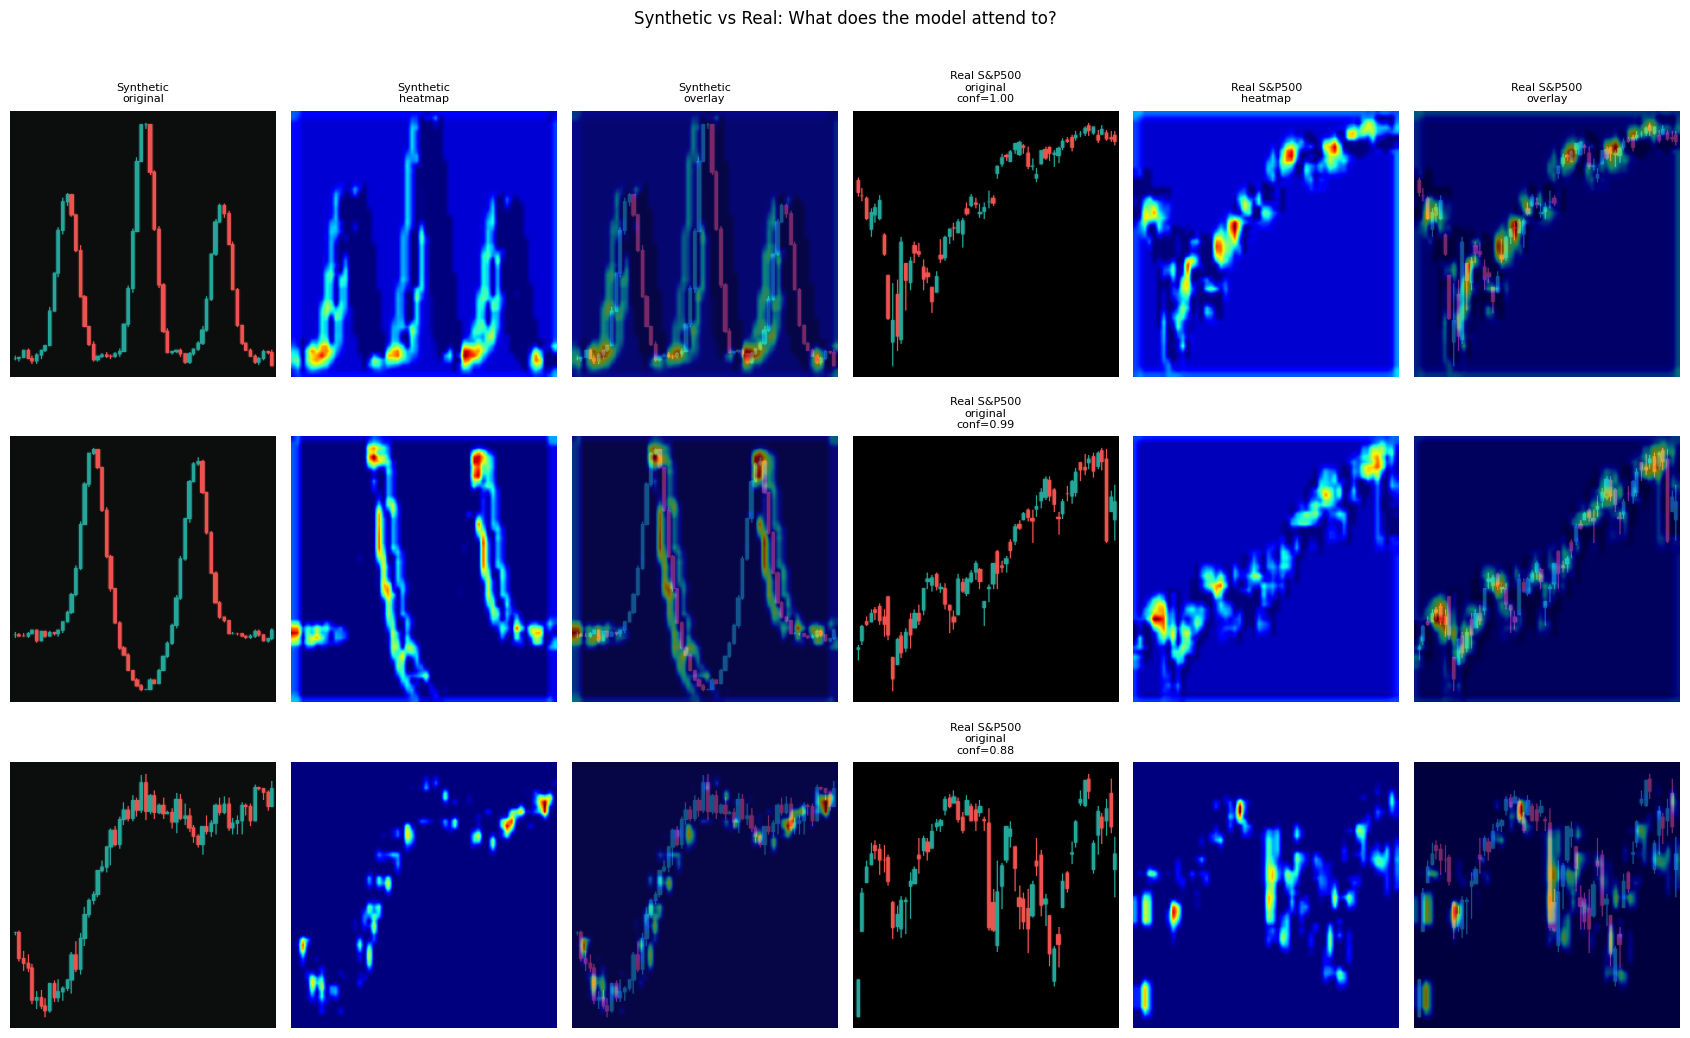

Saved gradcam_synthetic_vs_real.png


In [16]:
# pick up to 3 classes that actually appear in the real detections
from collections import Counter
pred_counts = Counter(d['class'] for _, d in real_samples)
top_classes = [cls for cls, _ in pred_counts.most_common(3)]
print('Showing classes:', top_classes)

cnn_cam = GradCAM(cnn_model, cnn_model.features[-1][0])

# cols: synthetic original | synthetic cam | synthetic overlay |
#        real original      | real cam      | real overlay
fig, axes = plt.subplots(len(top_classes), 6,
                          figsize=(17, 3.5 * len(top_classes)))
if len(top_classes) == 1:
    axes = axes[np.newaxis, :]

col_titles = ['Synthetic\noriginal', 'Synthetic\nheatmap', 'Synthetic\noverlay',
              'Real S&P500\noriginal', 'Real S&P500\nheatmap', 'Real S&P500\noverlay']

for row, cls in enumerate(top_classes):
    # --- synthetic sample ---
    syn_path   = sorted((SYNTHETIC_DIR / 'val' / cls).glob('*.png'))[0]
    syn_tensor = tfm(Image.open(syn_path).convert('RGB')).unsqueeze(0).to(device)
    cam_s, _   = cnn_cam(syn_tensor, class_idx=CLASS_NAMES.index(cls))
    ov_s, orig_s = make_overlay(syn_tensor, cam_s)

    # --- real sample (highest confidence for this class) ---
    cls_samples = [(img, d) for img, d in real_samples if d['class'] == cls]
    cls_samples.sort(key=lambda x: x[1]['conf'], reverse=True)
    real_img, real_det = cls_samples[0]
    real_tensor = tfm(real_img).unsqueeze(0).to(device)
    cam_r, _    = cnn_cam(real_tensor, class_idx=CLASS_NAMES.index(cls))
    ov_r, orig_r = make_overlay(real_tensor, cam_r)

    data_list = [orig_s, cam_s, ov_s, orig_r, cam_r, ov_r]

    for col, (ax, data) in enumerate(zip(axes[row], data_list)):
        ax.imshow(data, cmap='jet' if col in (1, 4) else None)
        ax.axis('off')
        if row == 0:
            ax.set_title(col_titles[col], fontsize=8)

    conf = real_det['conf']
    axes[row, 0].set_ylabel(f'{cls.replace("_", chr(10))}\n(synthetic)',
                             fontsize=7, rotation=0, labelpad=80, va='center')
    axes[row, 3].set_title(f'Real S&P500\noriginal\nconf={conf:.2f}', fontsize=8)

plt.suptitle('Synthetic vs Real: What does the model attend to?', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'gradcam_synthetic_vs_real.png', dpi=100, bbox_inches='tight')
plt.show()
cnn_cam.remove()
print('Saved gradcam_synthetic_vs_real.png')


### Correct vs Wrong Predictions on Real Data

We compute 5-day forward returns for each detection to label it correct or wrong,
then show Grad-CAM on both groups side by side.

This is the most direct way to check if attention patterns differ between
cases where the model happened to be right vs where it was wrong.

Correct predictions : 29  (showing 3)
Wrong predictions   : 46  (showing 3)


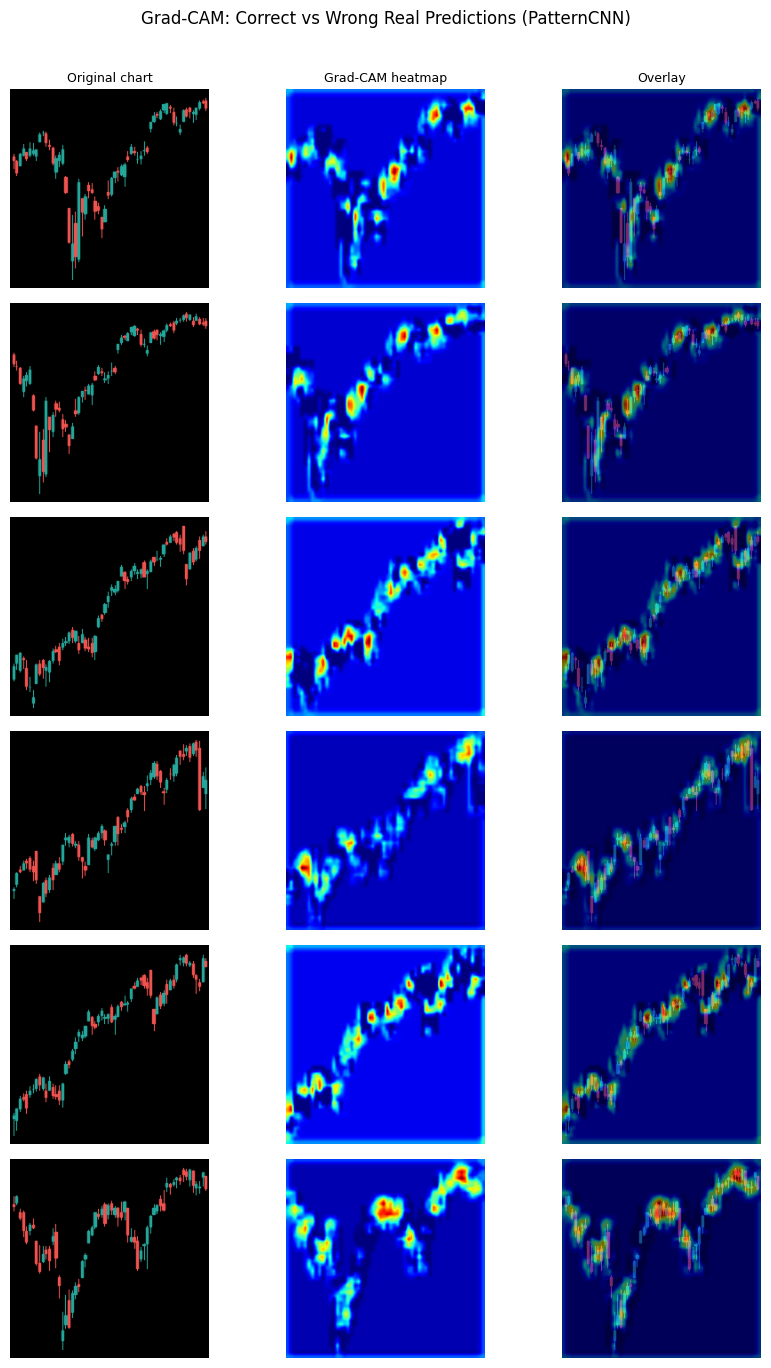

Saved gradcam_correct_vs_wrong.png


In [17]:
FORWARD_DAYS = 5

# label each real sample as correct or wrong using 5-day forward return
labeled = []
for img, det in real_samples:
    det_date  = pd.Timestamp(det['date'])
    future    = df.index[df.index >= det_date]
    if len(future) < FORWARD_DAYS + 1:
        continue
    entry_price = df.loc[future[0], 'Close']
    exit_price  = df.loc[future[FORWARD_DAYS], 'Close']
    fwd_ret     = (exit_price / entry_price) - 1

    if det['direction'] == 'bullish':
        correct = fwd_ret > 0
    else:
        correct = fwd_ret < 0

    labeled.append((img, det, fwd_ret, correct))

correct_ones = [x for x in labeled if     x[3]]
wrong_ones   = [x for x in labeled if not x[3]]

# sort by confidence to get clearest examples
correct_ones.sort(key=lambda x: x[1]['conf'], reverse=True)
wrong_ones.sort(  key=lambda x: x[1]['conf'], reverse=True)

N_SHOW = min(3, len(correct_ones), len(wrong_ones))
print(f'Correct predictions : {len(correct_ones)}  (showing {N_SHOW})')
print(f'Wrong predictions   : {len(wrong_ones)}  (showing {N_SHOW})')

cnn_cam = GradCAM(cnn_model, cnn_model.features[-1][0])

fig, axes = plt.subplots(N_SHOW * 2, 3, figsize=(9, 4.5 * N_SHOW))

for i in range(N_SHOW):
    for group_idx, (group, label, color) in enumerate([
        (correct_ones, 'CORRECT', 'limegreen'),
        (wrong_ones,   'WRONG',   'tomato'),
    ]):
        row = i * 2 + group_idx
        img, det, fwd_ret, _ = group[i]

        tensor = tfm(img).unsqueeze(0).to(device)
        cam, _ = cnn_cam(tensor, class_idx=CLASS_NAMES.index(det['class']))
        overlay, orig = make_overlay(tensor, cam)

        axes[row, 0].imshow(orig)
        axes[row, 1].imshow(cam, cmap='jet')
        axes[row, 2].imshow(overlay)

        direction_arrow = '↑' if det['direction'] == 'bullish' else '↓'
        ret_sign = '+' if fwd_ret > 0 else ''
        title = (f'[{label}] {det["class"].replace("_"," ")} {direction_arrow}  '
                 f'conf={det["conf"]:.2f}  5d return={ret_sign}{fwd_ret*100:.1f}%')

        axes[row, 0].set_ylabel(title, fontsize=7, rotation=0,
                                 labelpad=5, va='center', color=color)
        for ax in axes[row]:
            ax.axis('off')
            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(2)

axes[0, 0].set_title('Original chart', fontsize=9)
axes[0, 1].set_title('Grad-CAM heatmap', fontsize=9)
axes[0, 2].set_title('Overlay', fontsize=9)

plt.suptitle('Grad-CAM: Correct vs Wrong Real Predictions (PatternCNN)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'gradcam_correct_vs_wrong.png', dpi=100, bbox_inches='tight')
plt.show()
cnn_cam.remove()
print('Saved gradcam_correct_vs_wrong.png')
